# Maximum Likelihood Estimation.

## Libraries and Data.


### Importing the libraries.


In [ ]:
from itertools import chain

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import norm
from scipy import special
import torch
from tqdm import tqdm

from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.sym import GaussianMixtureModel

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading the data.


In [ ]:
PATH = "../../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


### Subsampling the data.


In [ ]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


### Applying Tranformation.


In [ ]:
cofactor = 100
key_arcsin = f"X_arcsinh_cof{cofactor}" 
adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
adata


### Initializing DataManager

In [ ]:
# data manager
datamanager = DataManager(
    adata,
    sample_rep=key_arcsin
)
data = datamanager.get_data()


### Defining DataLoader.

In [ ]:
# data loading
BATCH_SIZE = 2048
dataloader = SequentialDataLoader(
    data,
    batch_size=BATCH_SIZE,
)


## MLE of GMM model.

### Defining various setting that we need.

In [ ]:
# settings
DIM = adata.X.shape[1]
N_COMPS = 2


### Initializing the Parameters.

In [18]:
homoskedastic = False
weights = torch.nn.Parameter(
    torch.zeros(1, N_COMPS, requires_grad=True, device="cuda")
)
means = torch.nn.Parameter(
    torch.randn(N_COMPS, DIM, requires_grad=True, device="cuda")
)
covs = torch.nn.Parameter(
    torch.randn(N_COMPS, 1  if homoskedastic else DIM, requires_grad=True, device="cuda")
)
means.shape, covs.shape, weights.shape


(torch.Size([2, 21]), torch.Size([2, 21]), torch.Size([1, 2]))

### Definining function for computing loss.

In [19]:
def compute_gmm_loss(samples, means, covs, weights, homoskedastic=homoskedastic):

    assert samples.ndim == 2
    assert means.ndim == 2
    assert weights.ndim == 2
    
    B, D = samples.shape
    K, _ = means.shape

    assert weights.shape[1] == K, weights.shape
    assert weights.shape[0] == 1, weights.shape
    assert means.shape[1] == D, means.shape

    if homoskedastic:
        assert covs.shape == (K, 1), covs.shape
        covs = torch.nn.functional.softplus(covs)
        covs = torch.stack([torch.eye(D, device=covs.device)*covs[k] for k in range(K)], dim=0)
    else:
        assert covs.shape == (K, D), covs.shape
        covs = torch.nn.functional.softplus(covs)
        covs = torch.stack([torch.diag(covs[k]) for k in range(K)], dim=0)
    assert covs.shape == (K, D, D), covs.shape

    def compute_log_gaussian_likelihood(samples, mean, cov):
        """
        Numerically stable log-likelihood computation for a multivariate Gaussian.
        """
        B, D = samples.shape
        diff = samples - mean  # (B, D)

        Icov = torch.linalg.inv(cov)  # (D, D)
        mahalanobis = torch.einsum('bi,ij,bj->b', diff, Icov, diff)  # (B,)
        
        log_det = torch.logdet(cov)
        log_norm = -0.5 * (D * np.log(2 * np.pi) + log_det)
        
        return log_norm - 0.5 * mahalanobis  # (B,)
    
    log_probs = torch.zeros(B, K, device=means.device)
    for comp in range(K):
        log_probs[:, comp] = compute_log_gaussian_likelihood(samples, means[comp], covs[comp])

    # Normalize weights and apply log
    log_weights = torch.nn.functional.log_softmax(weights, dim=-1)  # (1, K)
    # Combine log-likelihood and log-weights
    log_mix_probs = torch.logsumexp(log_probs + log_weights, dim=1)  # (B,)

    return -log_mix_probs.mean()

with torch.no_grad():
    example = compute_gmm_loss(dataloader.sample()["state_data"], means, covs, weights)
print(example)


tensor(241.9926, device='cuda:0')


### Optimizing the Parameters.

loss: 237.40 weightstensor([[0.5226, 0.4774]], device='cuda:0', grad_fn=<SoftmaxBackward0>):   1%|          | 581/100000 [00:10<29:44, 55.72it/s] 
loss: 48.31 weightstensor([[0.4984, 0.5016]], device='cuda:0', grad_fn=<SoftmaxBackward0>): 100%|█████████▉| 99999/100000 [08:10<00:00, 201.86it/s] 

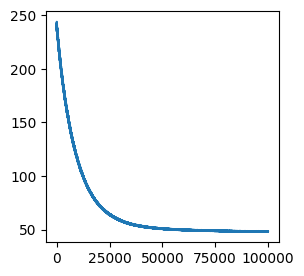

In [20]:
# defining optimizer
optimizer = torch.optim.Adam(
    [
        weights, means, covs
    ]
    , lr=1e-4, #weight_decay=.01
)

# iteration
n_grad_steps = 100_000
iterator = range(n_grad_steps)
pbar = tqdm(iterator)

# storing progress
rec_loss_history = np.zeros((n_grad_steps, ))
reg_loss_history = np.zeros((n_grad_steps, ))
loss_history = np.zeros((n_grad_steps, ))


# iterating over gradient steps
for grad_step in iterator:
    # sampling
    states = dataloader.sample()["state_data"]
    loss = compute_gmm_loss(states, means, covs, weights)
    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # logging
    if (grad_step + 1)%100==0:
        pbar.set_description(f"loss: {loss.item():.2f} weights{torch.nn.functional.softmax(weights, dim=-1)}")
    pbar.update()
    loss_history[grad_step] = loss.item()

# plotting
plt.plot(loss_history)


### Visualizing the learned parameters.

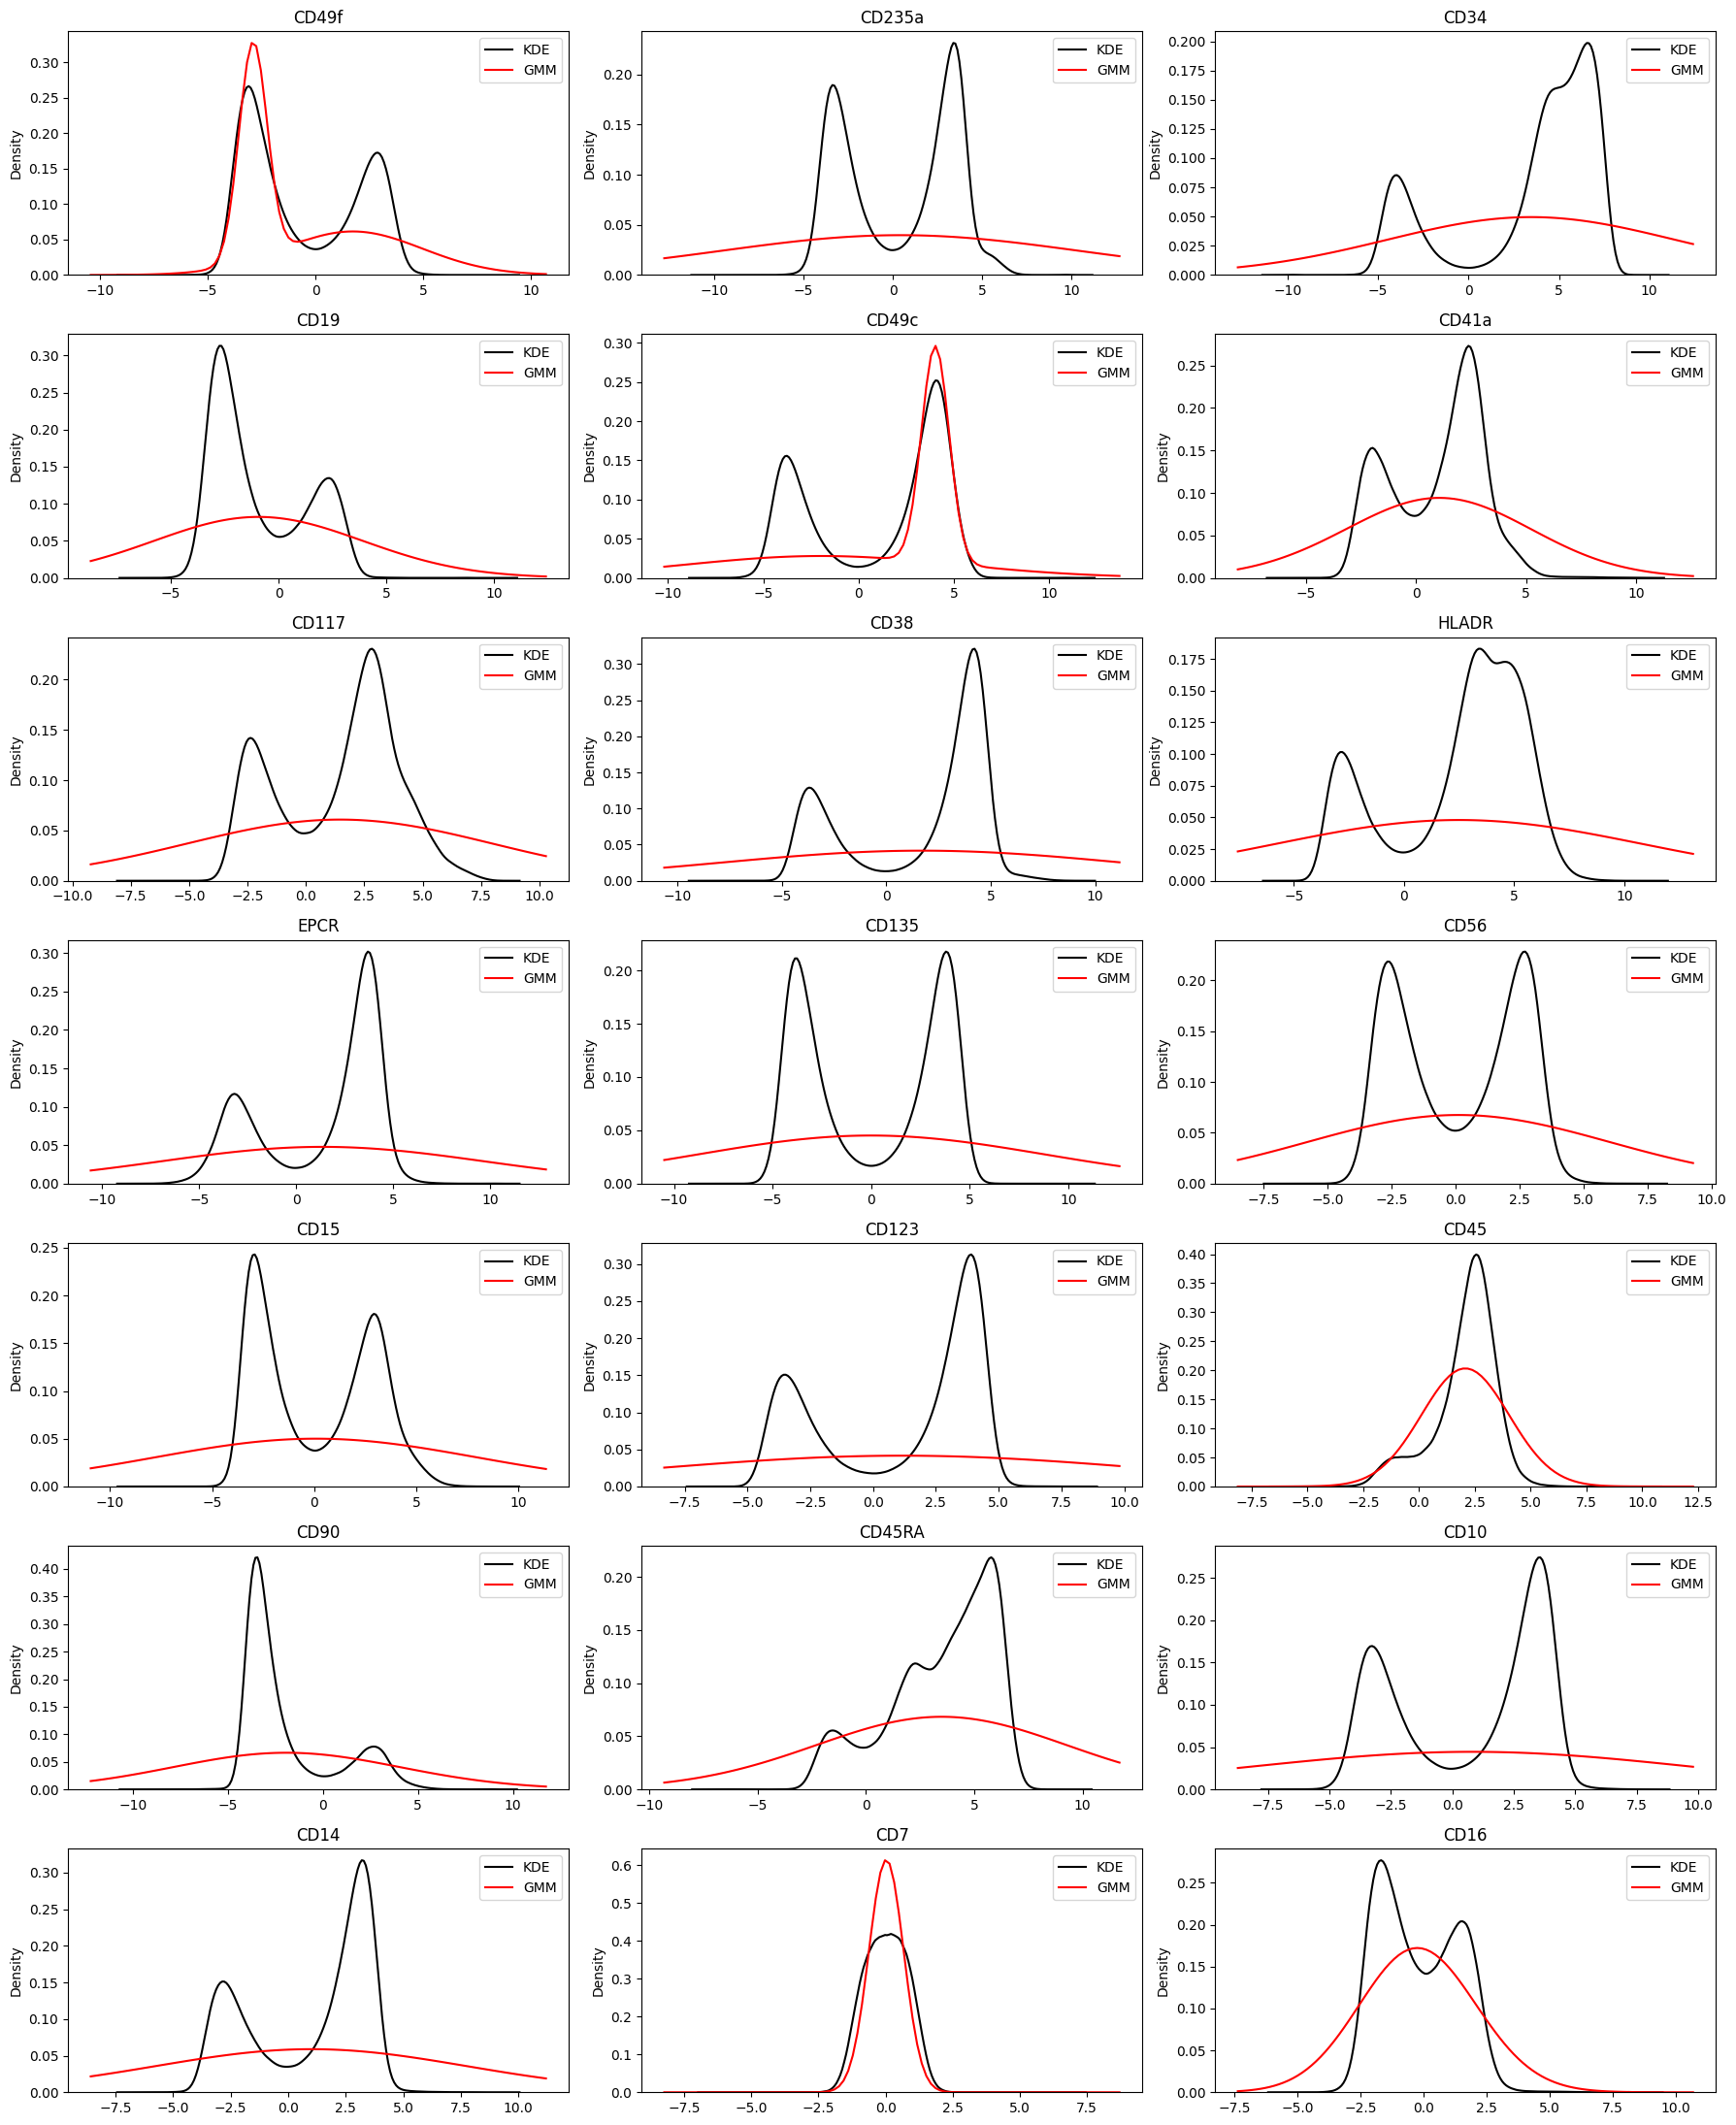

In [22]:
int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}

if isinstance(weights, torch.Tensor):
    weights = weights.squeeze().detach().cpu().numpy()    # shape (5,)
    means = means.detach().cpu().numpy()                  # shape (5, 21)
    covs = covs.squeeze().detach().cpu().numpy()          # shape (5,)
weight = special.softmax(weights) 
covs = special.softplus(covs) 
# stds = np.sqrt(covs)[:, None]          # shape (5, 1)

# Your data: shape (N, 21)
# data = torch.randn(1000, 21).numpy()
data = adata.obsm[key_arcsin]
data = data

dims = means.shape[1]  # 21

fig, axs = plt.subplots(7, 3, figsize=(18, 22))
axs = axs.flatten()

for dim in range(dims):
    ax = axs[dim]

    # Define linspace over the data range for this dimension
    data_min = data[:, dim].min()
    data_max = data[:, dim].max()
    padding = 0.1 * (data_max - data_min)
    x_grid = np.linspace(data_min - padding, data_max + padding, 100)

    # KDE from data
    sns.kdeplot(data[:, dim], ax=ax, label='KDE', color='black')

    # GMM density over this dimension
    gmm_density = np.zeros_like(x_grid)
    for k in range(weights.shape[0]):
        w = weight[k]
        mu = means[k, dim]
        sigma = covs[k, dim] if not homoskedastic else covs[k]
        gmm_density += w * norm.pdf(x_grid, mu, sigma)

    ax.plot(x_grid, gmm_density, label='GMM', color='red')
    ax.set_title(f'{int2antibody[dim]}')
    ax.legend()

# Hide any unused subplots (in case dims < len(axs))
for i in range(dims, len(axs)):
    axs[i].axis('off')

plt.tight_layout()
plt.show()


### Bar plot of standard deviations.

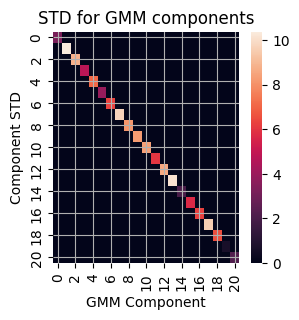

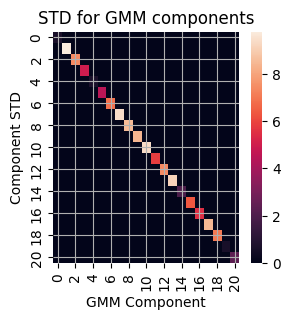

In [23]:
if homoskedastic:
    plt.figure()
    sns.barplot(x=np.arange(N_COMPS), y=covs)
    plt.title("STD for GMM components")
    plt.xlabel("GMM Component")
    plt.ylabel("Component STD")
    plt.grid(True)
    plt.show()
else:
    for comp in range(N_COMPS):
        plt.figure()
        sns.heatmap(np.diag(covs[comp]))
        plt.title("STD for GMM components")
        plt.xlabel("GMM Component")
        plt.ylabel("Component STD")
        plt.grid(True)
    plt.show()


### Bar plot of the weights.

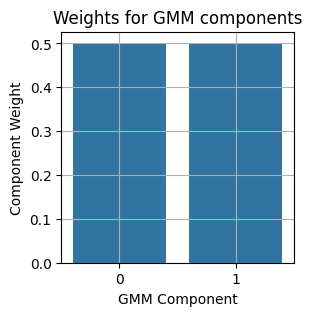

In [24]:
plt.figure()
sns.barplot(x=np.arange(N_COMPS), y=weight)
plt.title("Weights for GMM components")
plt.xlabel("GMM Component")
plt.ylabel("Component Weight")
plt.grid(True)
plt.show()


### Scatter plot of the components mean.

Text(0, 0.5, 'Mean GMM comp 1')

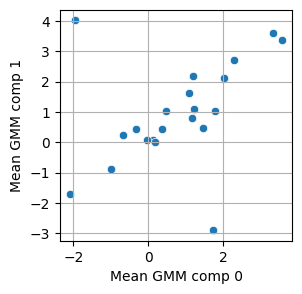

In [25]:
mean0 = means[0]
mean1 = means[1]
sns.scatterplot(x=mean0,y=mean1)
plt.grid(True)
plt.xlabel("Mean GMM comp 0")
plt.ylabel("Mean GMM comp 1")
